In [1]:
!pip install pyDOE2 tqdm
!pip install smt

  Preparing metadata (setup.py) ... done
  Created wheel for pyDOE2: filename=pyDOE2-1.3.0-py3-none-any.whl size=25523 sha256=9272a06db137a660b2512695e4ed97cafaf30cbfa0bd40d683a966b740cd0f4b
  Stored in directory: /root/.cache/pip/wheels/eb/43/4c/23f07750b9eefa81ef8d1a37f6a3ce1e6329b63312aa71150c
Successfully built pyDOE2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 120.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.6 MB/s eta 0:00:00


In [2]:
import os
base_dir = "results"
os.makedirs(base_dir, exist_ok=True)
adam_dir = os.path.join(base_dir, "adam")
adam_dir_plots = os.path.join(adam_dir, "adam_dir_plots")
adam_dir_pretraining = os.path.join(adam_dir, "adam_dir_pretraining")
stridge_dir = os.path.join(base_dir, "stridge")
general_dir = os.path.join(base_dir, "general")
os.makedirs(adam_dir, exist_ok=True)
os.makedirs(adam_dir_plots, exist_ok=True)
os.makedirs(adam_dir_pretraining, exist_ok=True)
os.makedirs(stridge_dir, exist_ok=True)
os.makedirs(general_dir, exist_ok=True)

<>:1012: SyntaxWarning: invalid escape sequence '\l'
<>:1012: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_564/781149179.py:1012: SyntaxWarning: invalid escape sequence '\l'
  plt.title('Identified $\lambda$')


Device mapping:
/job:localhost/replica:0/task:0/device:GPU:0 -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:00:04.0, compute capability: 8.0

Adam pretraining starts
It: 0, Log Loss: 2.299e-01, loss_u: 1.258230e+00, loss_f: 2.106138e-04, loss_lambda: 1.988262e-09, Time: 15.68
It: 10, Log Loss: 1.434e-01, loss_u: 1.154146e+00, loss_f: 2.791439e-06, loss_lambda: 1.484630e-08, Time: 1.18
It: 20, Log Loss: 9.304e-02, loss_u: 1.097438e+00, loss_f: 6.374115e-05, loss_lambda: 3.981274e-08, Time: 1.16
It: 30, Log Loss: 4.808e-02, loss_u: 1.049165e+00, loss_f: 8.853831e-05, loss_lambda: 1.044199e-07, Time: 1.16
It: 40, Log Loss: 2.676e-02, loss_u: 1.027025e+00, loss_f: 9.503406e-05, loss_lambda: 1.408845e-07, Time: 1.15
It: 50, Log Loss: 6.870e-03, loss_u: 1.006814e+00, loss_f: 7.918290e-05, loss_lambda: 1.916601e-07, Time: 1.16
It: 60, Log Loss: 1.510e-02, loss_u: 1.015106e+00, loss_f: 1.047710e-04, loss_lambda: 2.576058e-07, Time: 1.16
It: 70, Log Loss: -1.798e-02, loss_u: 9.8205

/tmp/ipykernel_564/781149179.py:999: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure()


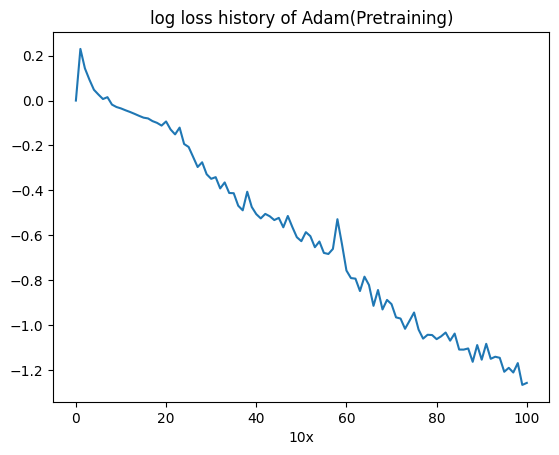

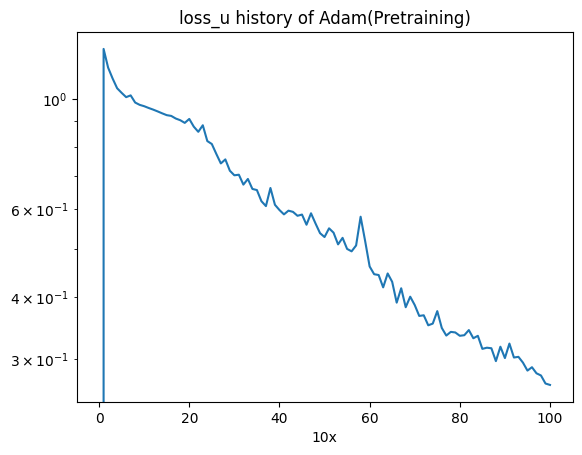

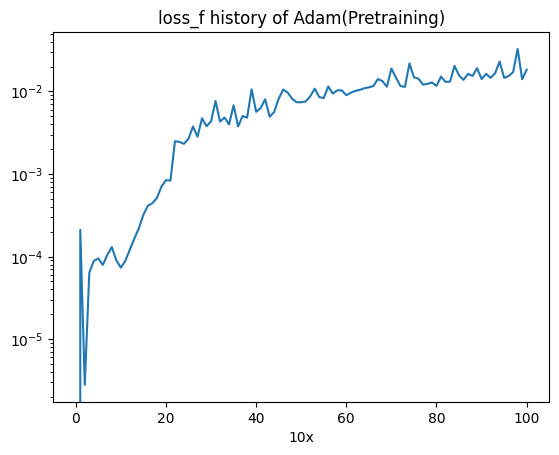

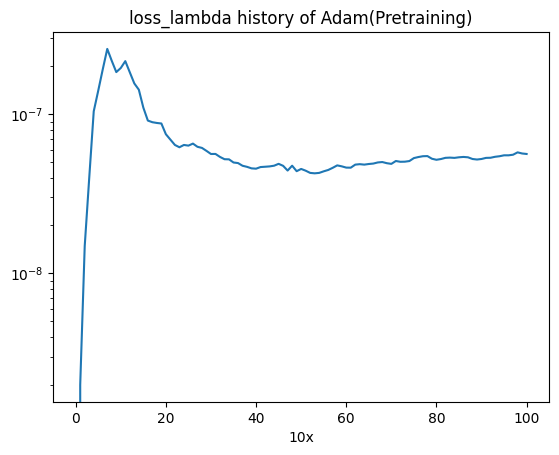

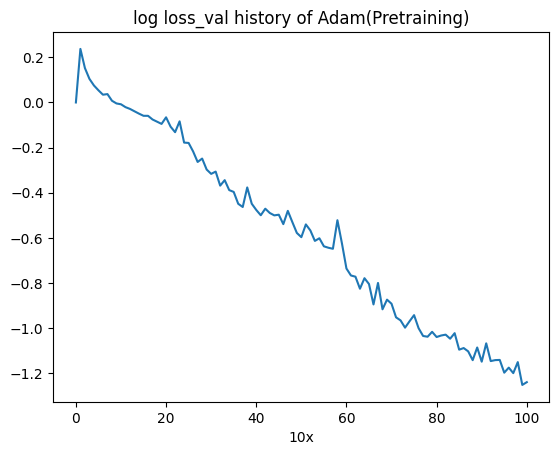

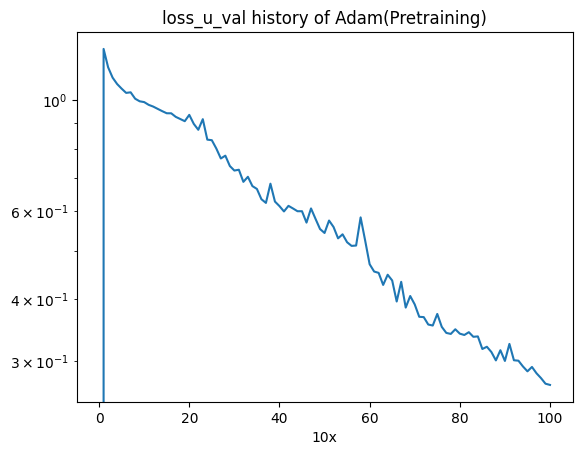

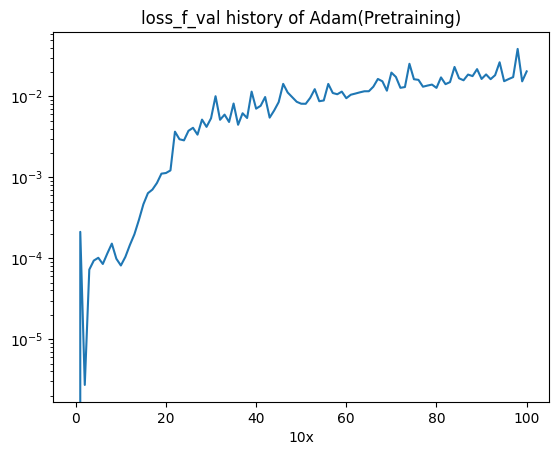

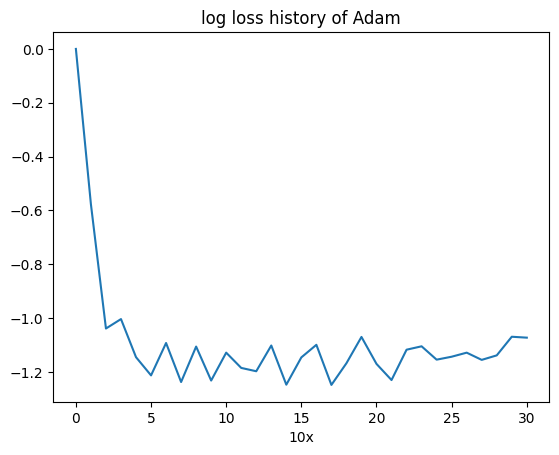

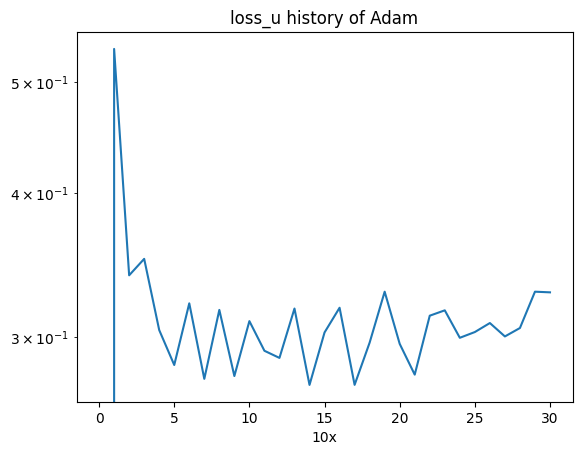

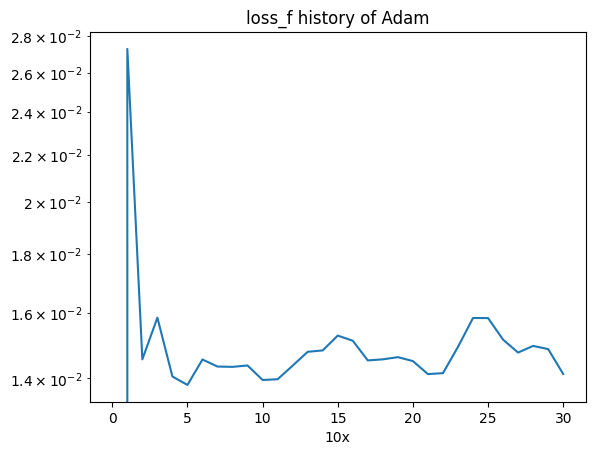

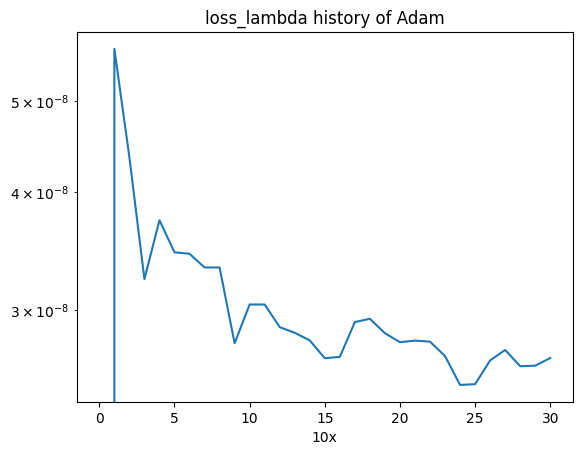

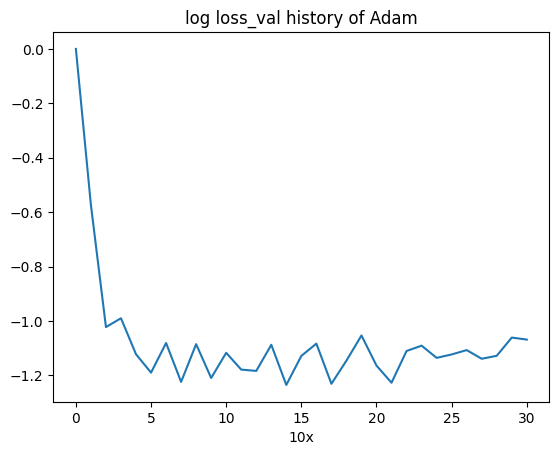

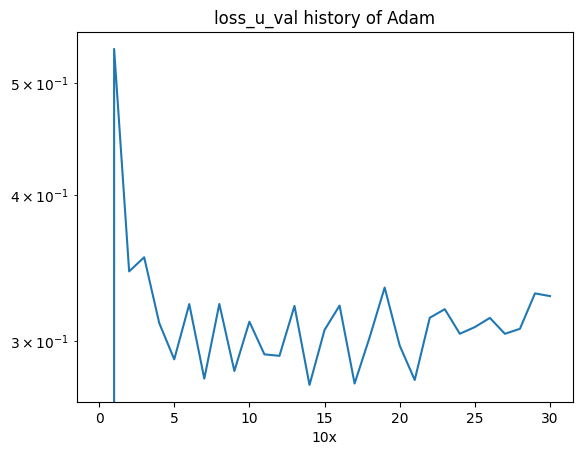

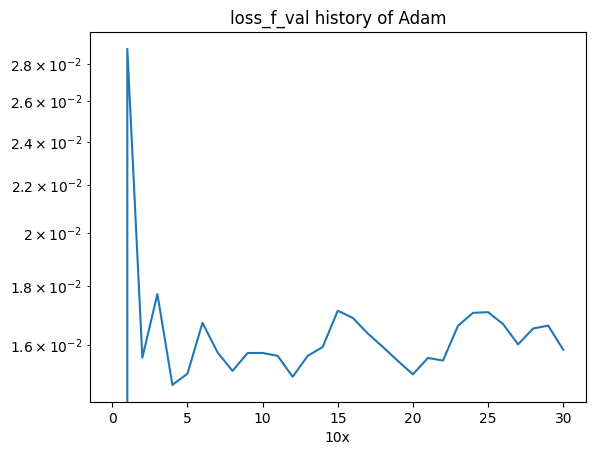

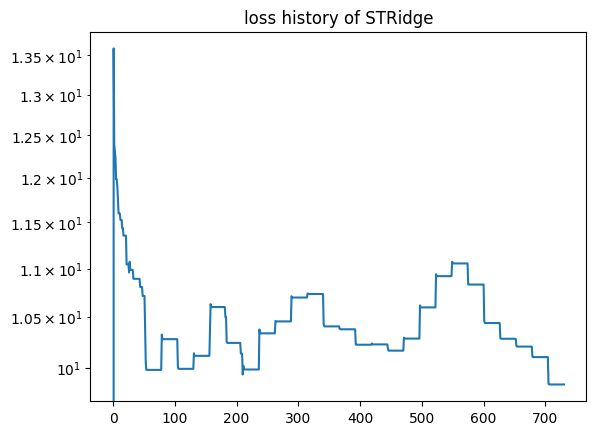

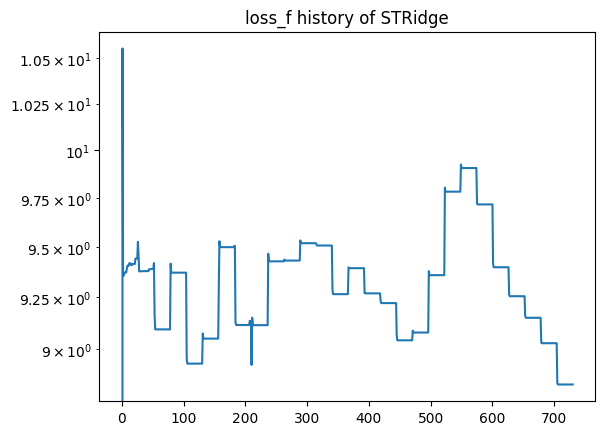

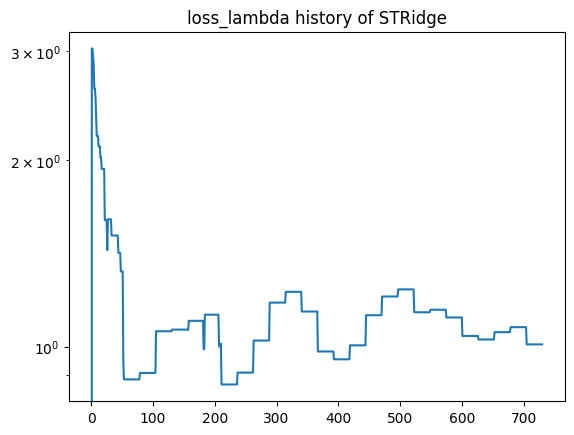

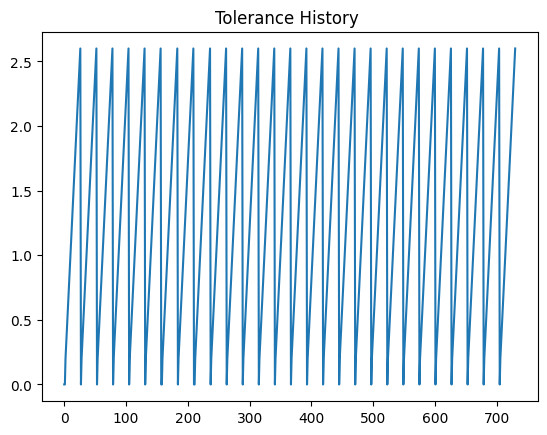

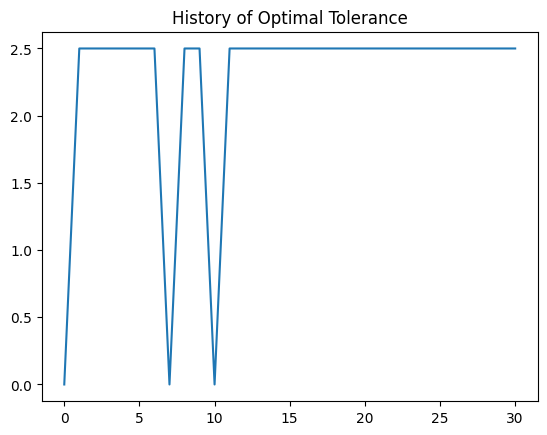

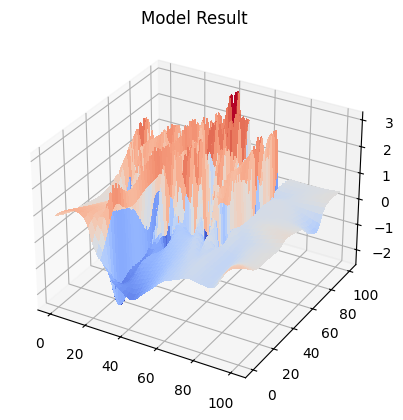

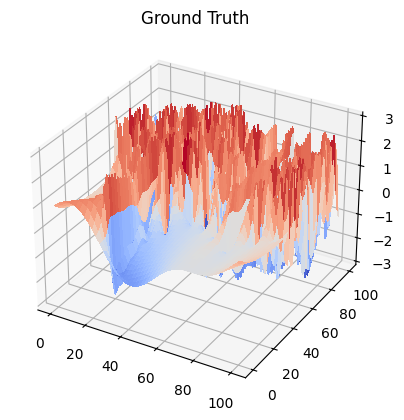

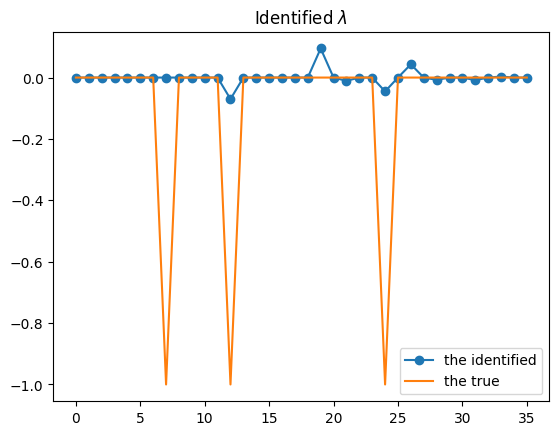

In [4]:
# =============================================================================
# Physics-informed learning of governing equations from scarce data
# Zhao Chen, Yang Liu, and Hao Sun
# 2021. Northeastern University

# =============================================================================
# import tensorflow as tf
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
from scipy.interpolate import griddata
from scipy.spatial import distance
#from mpl_toolkits.axes_grid1 import make_axes_locatable
#import matplotlib.gridspec as gridspec
import time
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
#import sobol_seq
# from pyDOE import lhs
from smt.sampling_methods import LHS

with tf.device('/device:GPU:1'):
    def lhs(dim, samples):
          xlimits = np.array([[0.0, 1.0]] * dim)
          sampling = LHS(xlimits=xlimits)
          return sampling(samples)

    # L-BFGS-S loss history
    # loss_history = np.array([0])
    # loss_u_history = np.array([0])
    # loss_f_history = np.array([0])
    # loss_lambda1_history = np.array([0])
    # lambda1_history = np.zeros((36,1))
    # loss_history_val = np.array([0])
    # loss_u_history_val = np.array([0])
    # loss_f_history_val = np.array([0])

    step = 0

    # Adam loss history
    loss_history_Adam = np.array([0])
    loss_u_history_Adam = np.array([0])
    loss_f_history_Adam = np.array([0])
    loss_lambda1_history_Adam = np.array([0])
    lambda1_history_Adam = np.zeros((36,1))
    loss_history_Adam_val = np.array([0])
    loss_u_history_Adam_val = np.array([0])
    loss_f_history_Adam_val = np.array([0])

    # STRidge loss history
    loss_history_STRidge = np.array([0])
    loss_f_history_STRidge = np.array([0])
    loss_lambda1_history_STRidge = np.array([0])
    optimaltol_history = np.array([0])
    tol_history_STRidge = np.array([0])
    lambda_history_STRidge = np.zeros((36, 1))
    ridge_append_counter_STRidge = np.array([0])

    # Loss histories for pretraining
    # L-BFGS-B(Pretrain)
    # loss_history_Pretrain = np.array([0])
    # loss_u_history_Pretrain = np.array([0])
    # loss_f_history_Pretrain = np.array([0])
    # loss_lambda1_history_Pretrain = np.array([0])
    # loss_history_val_Pretrain = np.array([0])
    # loss_u_history_val_Pretrain = np.array([0])
    # loss_f_history_val_Pretrain = np.array([0])
    # lambda1_history_Pretrain = np.zeros((36,1))
    # step_Pretrain = 0

    # Adam(Pretrain)
    loss_history_Adam_Pretrain = np.array([0])
    loss_u_history_Adam_Pretrain = np.array([0])
    loss_f_history_Adam_Pretrain = np.array([0])
    loss_lambda1_history_Adam_Pretrain = np.array([0])
    lambda1_history_Adam_Pretrain = np.zeros((36,1))
    loss_history_Adam_val_Pretrain = np.array([0])
    loss_u_history_Adam_val_Pretrain = np.array([0])
    loss_f_history_Adam_val_Pretrain = np.array([0])

    # Alter loss history
    loss_history_Alter = np.array([0])
    loss_u_history_Alter = np.array([0])
    loss_f_history_Alter = np.array([0])
    loss_lambda1_history_Alter = np.array([0])
    loss_history_Alter_val = np.array([0])
    loss_u_history_Alter_val = np.array([0])
    loss_f_history_Alter_val = np.array([0])
    lambda1_history_Alter = np.zeros((36, 1))

    np.random.seed(1234)
    tf.set_random_seed(1234)

    class PhysicsInformedNN:
# =============================================================================
#     Inspired by Raissi, Maziar, Paris Perdikaris, and George E. Karniadakis.
#     "Physics-informed neural networks: A deep learning framework for solving forward and inverse problems
#     involving nonlinear partial differential equations." Journal of Computational Physics 378 (2019): 686-707.
# =============================================================================
        # Initialize the class
        def __init__(self, X, u, X_f, X_val, u_val, layers, lb, ub):

            self.lb = lb
            self.ub = ub
            self.layers = layers

            # Initialize NNs and lambda1
            self.weights, self.biases = self.initialize_NN(layers)
            self.lambda1 = tf.Variable(tf.zeros([36, 1], dtype=tf.float32), dtype=tf.float32, name = 'lambda')


            config=tf.ConfigProto(allow_soft_placement=True, log_device_placement=True)
            config.gpu_options.allow_growth = True
            self.sess = tf.Session(config = config)

            # Specify the list of trainable variables
            var_list_1 = self.biases + self.weights

            var_list_Pretrain = self.biases + self.weights
            var_list_Pretrain.append(self.lambda1)

            ######### Training data ################
            self.x = X[:,0:1]
            self.t = X[:,1:2]
            self.u = u
            self.x_f = X_f[:, 0:1]
            self.t_f = X_f[:, 1:2]

            self.x_tf = tf.placeholder(tf.float32, shape=[None, self.x.shape[1]])
            self.t_tf = tf.placeholder(tf.float32, shape=[None, self.t.shape[1]])
            self.u_tf = tf.placeholder(tf.float32, shape=[None, self.u.shape[1]])
            self.x_f_tf = tf.placeholder(tf.float32, shape=[None, self.x_f.shape[1]])
            self.t_f_tf = tf.placeholder(tf.float32, shape=[None, self.t_f.shape[1]])

            self.u_pred = self.net_u(self.x_tf, self.t_tf)
            self.f_pred, self.Phi_pred, self.u_t_pred = self.net_f(self.x_f_tf, self.t_f_tf, X_f.shape[0])

            self.loss_u = tf.reduce_mean(tf.square(self.u_tf - self.u_pred))
            self.loss_f = tf.reduce_mean(tf.square(self.f_pred))
            self.loss_lambda = 1e-7*tf.norm(self.lambda1, ord=1)
            self.loss = tf.log(self.loss_u  + self.loss_f + self.loss_lambda) # log loss

            ######### Validation data ################
            self.x_val = X_val[:,0:1]
            self.t_val = X_val[:,1:2]
            self.u_val = u_val

            self.x_val_tf = tf.placeholder(tf.float32, shape=[None, self.x_val.shape[1]])
            self.t_val_tf = tf.placeholder(tf.float32, shape=[None, self.t_val.shape[1]])
            self.u_val_tf = tf.placeholder(tf.float32, shape=[None, self.u_val.shape[1]])

            self.u_val_pred = self.net_u(self.x_val_tf, self.t_val_tf)
            self.f_val_pred, _, _ = self.net_f(self.x_val_tf, self.t_val_tf, u_val.shape[0])

            self.loss_u_val = tf.reduce_mean(tf.square(self.u_val_tf - self.u_val_pred))
            self.loss_f_val = tf.reduce_mean(tf.square(self.f_val_pred))
            self.loss_val = tf.log(self.loss_u_val  + self.loss_f_val) # log loss

            ######### Optimizor #########################
#             self.optimizer = tf.contrib.opt.ScipyOptimizerInterface(self.loss,
#                                                                     var_list = var_list_1,
# #                                                                    L-BFGS-B
#                                                                     method = 'L-BFGS-B',
#                                                                     options = {'maxiter': 2000,
#                                                                                'maxfun': 2000,
#                                                                                'maxcor': 50,
#                                                                                'maxls': 50,
#                                                                                'ftol' : 0.1 * np.finfo(float).eps})

#             self.optimizer_Pretrain = tf.contrib.opt.ScipyOptimizerInterface(self.loss,
#                                                                              var_list = var_list_Pretrain,
#         #                                                                    L-BFGS-B
#                                                                             method = 'L-BFGS-B',
#                                                                             options = {'maxiter': 80000,
#                                                                                        'maxfun': 80000,
#                                                                                        'maxcor': 50,
#                                                                                        'maxls': 50,
#                                                                                        'ftol' : 0.1 * np.finfo(float).eps})

            # the default learning rate = 0.001， beta1 = 0.9, beta2 = 0.999
            self.optimizer_Adam_Pretrain = tf.train.AdamOptimizer(learning_rate = 0.005)
            self.train_op_Adam_Pretrain = self.optimizer_Adam_Pretrain.minimize(self.loss, var_list = var_list_Pretrain)

            self.optimizer_Adam = tf.train.AdamOptimizer(learning_rate = 0.001, beta1 = 0.999, beta2 = 0.9)
            self.train_op_Adam = self.optimizer_Adam.minimize(self.loss, var_list = var_list_1)


            self.tf_dict = {self.x_tf: self.x, self.t_tf: self.t, self.u_tf: self.u,
                       self.x_f_tf: self.x_f, self.t_f_tf: self.t_f,
                       self.x_val_tf: self.x_val, self.t_val_tf: self.t_val, self.u_val_tf: self.u_val}

            init = tf.global_variables_initializer()
            self.sess.run(init)

        def initialize_NN(self, layers):
            weights = []
            biases = []
            num_layers = len(layers)
            for l in range(0,num_layers-1):
                W = self.xavier_init(size=[layers[l], layers[l+1]])
                b = tf.Variable(tf.zeros([1,layers[l+1]], dtype=tf.float32), dtype=tf.float32, name = 'b')
                weights.append(W)
                biases.append(b)
            return weights, biases

        def xavier_init(self, size):
            in_dim = size[0]
            out_dim = size[1]
            xavier_stddev = np.sqrt(2/(in_dim + out_dim))
            return tf.Variable(tf.truncated_normal([in_dim, out_dim], stddev=xavier_stddev), dtype=tf.float32, name = 'W')

        def neural_net(self, X, weights, biases):
            num_layers = len(weights) + 1

            H = 2.0*(X - self.lb)/(self.ub - self.lb) - 1.0
            for l in range(0,num_layers-2):
                W = weights[l]
                b = biases[l]
                H = tf.tanh(tf.add(tf.matmul(H, W), b))
            W = weights[-1]
            b = biases[-1]
            Y = tf.add(tf.matmul(H, W), b)
            return Y

        def net_u(self, x, t):
            u = self.neural_net(tf.concat([x,t],1), self.weights, self.biases)
            return u

        def net_f(self, x, t, N_f):
            u = self.net_u(x,t)
            u_t = tf.gradients(u, t)[0]
            u_x = tf.gradients(u, x)[0]
            u_xx = tf.gradients(u_x, x)[0]
            u_xxx = tf.gradients(u_xx, x)[0]
            u_xxxx = tf.gradients(u_xxx, x)[0]
            u_xxxxx = tf.gradients(u_xxxx, x)[0]

            Phi = tf.concat([tf.constant(1, shape=[N_f, 1], dtype=tf.float32), u, u**2, u**3, u**4, u**5, u_x, u*u_x, u**2*u_x,
                             u**3*u_x, u**4*u_x, u**5*u_x, u_xx, u*u_xx, u**2*u_xx, u**3*u_xx, u**4*u_xx, u**5*u_xx, u_xxx, u*u_xxx,
                             u**2*u_xxx, u**3*u_xxx, u**4*u_xxx, u**5*u_xxx, u_xxxx, u*u_xxxx, u**2*u_xxxx, u**3*u_xxxx, u**4*u_xxxx,
                             u**5*u_xxxx, u_xxxxx, u*u_xxxxx, u**2*u_xxxxx, u**3*u_xxxxx, u**4*u_xxxxx, u**5*u_xxxxx], 1)

            self.library_description = ['1',
                         'u', 'u**2', 'u**3', 'u**4', 'u**5',
                         'u_x', 'u*u_x', 'u**2*u_x', 'u**3*u_x', 'u**4*u_x', 'u**5*u_x',
                         'u_xx', 'u*u_xx', 'u**2*u_xx', 'u**3*u_xx', 'u**4*u_xx', 'u**5*u_xx',
                         'u_xxx', 'u*u_xxx', 'u**2*u_xxx', 'u**3*u_xxx', 'u**4*u_xxx', 'u**5*u_xxx',
                         'u_xxxx', 'u*u_xxxx', 'u**2*u_xxxx', 'u**3*u_xxxx', 'u**4*u_xxxx', 'u**5*u_xxxx',
                         'u_xxxxx', 'u*u_xxxxx', 'u**2*u_xxxxx', 'u**3*u_xxxxx', 'u**4*u_xxxxx', 'u**5*u_xxxxx']

            f = tf.matmul(Phi, self.lambda1) - u_t

            return f, Phi, u_t

        def callback(self, loss, lambda1, loss_u, loss_f, loss_lambda, loss_val, loss_u_val, loss_f_val):
            global step
            step = step+1
            if step % 10 == 0:

                global loss_history
                global lambda1_history
                global loss_u_history
                global loss_f_history
                global loss_lambda1_history
                global loss_history_val
                global loss_u_history_val
                global loss_f_history_val

                loss_history = np.append(loss_history, loss)
                lambda1_history = np.append(lambda1_history, lambda1, axis=1)
                loss_u_history = np.append(loss_u_history, loss_u)
                loss_f_history = np.append(loss_f_history, loss_f)
                loss_lambda1_history = np.append(loss_lambda1_history, loss_lambda)
                loss_history_val = np.append(loss_history_val, loss_val)
                loss_u_history_val = np.append(loss_u_history_val, loss_u_val)
                loss_f_history_val = np.append(loss_f_history_val, loss_f_val)

        # def callback_Pretrain(self, loss, lambda1, loss_u, loss_f, loss_lambda, loss_val, loss_u_val, loss_f_val):
        #     global step_Pretrain
        #     step_Pretrain = step_Pretrain+1
        #     if step_Pretrain % 10 == 0:
        #         print('It: %d, Log Loss: %e, loss_u: %e, loss_f: %e, loss_lambda: %e' % (step, loss, loss_u, loss_f, loss_lambda))

        #         global loss_history_Pretrain
        #         global lambda1_history_Pretrain
        #         global loss_u_history_Pretrain
        #         global loss_f_history_Pretrain
        #         global loss_lambda1_history_Pretrain
        #         global loss_history_val_Pretrain
        #         global loss_u_history_val_Pretrain
        #         global loss_f_history_val_Pretrain

        #         loss_history_Pretrain = np.append(loss_history_Pretrain, loss)
        #         lambda1_history_Pretrain = np.append(lambda1_history_Pretrain, lambda1, axis=1)
        #         loss_u_history_Pretrain = np.append(loss_u_history_Pretrain, loss_u)
        #         loss_f_history_Pretrain = np.append(loss_f_history_Pretrain, loss_f)
        #         loss_lambda1_history_Pretrain = np.append(loss_lambda1_history_Pretrain, loss_lambda)
        #         loss_history_val_Pretrain = np.append(loss_history_val_Pretrain, loss_val)
        #         loss_u_history_val_Pretrain = np.append(loss_u_history_val_Pretrain, loss_u_val)
        #         loss_f_history_val_Pretrain = np.append(loss_f_history_val_Pretrain, loss_f_val)

        def train(self, nIter):
            run_options = tf.RunOptions(report_tensor_allocations_upon_oom = True)
            # Pretraining,as a form of a good intialization
            # Adam Pretraining
            start_time = time.time()
            print('Adam pretraining starts')
            for it in range(1000):
                self.sess.run(self.train_op_Adam_Pretrain, feed_dict=self.tf_dict, options=run_options)

                # Print
                if it % 10 == 0:
                    elapsed = time.time() - start_time
                    loss, loss_u, loss_f, loss_lambda, lambda1_value, loss_val, loss_u_val, loss_f_val = self.sess.run([self.loss,
                                                                                                                        self.loss_u,
                                                                                                                        self.loss_f,
                                                                                                                        self.loss_lambda,
                                                                                                                        self.lambda1,
                                                                                                                        self.loss_val,
                                                                                                                        self.loss_u_val,
                                                                                                                        self.loss_f_val],
                                                                                                                        self.tf_dict)


                    print('It: %d, Log Loss: %.3e, loss_u: %e, loss_f: %e, loss_lambda: %e, Time: %.2f'
                          % (it, loss, loss_u, loss_f, loss_lambda, elapsed))

                    global loss_history_Adam_Pretrain
                    global lambda1_history_Adam_Pretrain
                    global loss_u_history_Adam_Pretrain
                    global loss_f_history_Adam_Pretrain
                    global loss_lambda1_history_Adam_Pretrain
                    global loss_history_Adam_val_Pretrain
                    global loss_u_history_Adam_val_Pretrain
                    global loss_f_history_Adam_val_Pretrain

                    loss_history_Adam_Pretrain = np.append(loss_history_Adam_Pretrain, loss)
                    lambda1_history_Adam_Pretrain = np.append(lambda1_history_Adam_Pretrain, lambda1_value, axis=1)
                    loss_u_history_Adam_Pretrain = np.append(loss_u_history_Adam_Pretrain, loss_u)
                    loss_f_history_Adam_Pretrain = np.append(loss_f_history_Adam_Pretrain, loss_f)
                    loss_lambda1_history_Adam_Pretrain = np.append(loss_lambda1_history_Adam_Pretrain, loss_lambda)
                    loss_history_Adam_val_Pretrain = np.append(loss_history_Adam_val_Pretrain, loss_val)
                    loss_u_history_Adam_val_Pretrain = np.append(loss_u_history_Adam_val_Pretrain, loss_u_val)
                    loss_f_history_Adam_val_Pretrain = np.append(loss_f_history_Adam_val_Pretrain, loss_f_val)

                    start_time = time.time()
            # L-BFGS-B Pretraining
            # print('L-BFGS-B pretraining begins')
            # self.optimizer_Pretrain.minimize(self.sess,
            #                         feed_dict = self.tf_dict,
            #                         fetches = [self.loss, self.lambda1, self.loss_u, self.loss_f, self.loss_lambda, self.loss_val,
            #                                    self.loss_u_val, self.loss_f_val],
            #                         loss_callback = self.callback_Pretrain)


            for it in range(nIter):
                # Adam 1
                start_time = time.time()
                print('Adam starts')
                for it in range(5):
                    self.sess.run(self.train_op_Adam, feed_dict=self.tf_dict, options=run_options)

                    # Print
                    if it % 10 == 0:
                        elapsed = time.time() - start_time
                        loss, loss_u, loss_f, loss_lambda, lambda1_value, loss_val, loss_u_val, loss_f_val = self.sess.run([self.loss, self.loss_u, self.loss_f, self.loss_lambda, self.lambda1, self.loss_val, self.loss_u_val, self.loss_f_val], self.tf_dict)
                        print('It: %d, Log Loss: %.3e, loss_u: %e, loss_f: %e, loss_lambda: %e, Time: %.2f'
                              % (it, loss, loss_u, loss_f, loss_lambda, elapsed))

                        global loss_history_Adam
                        global lambda1_history_Adam
                        global loss_u_history_Adam
                        global loss_f_history_Adam
                        global loss_lambda1_history_Adam
                        global loss_history_Adam_val
                        global loss_u_history_Adam_val
                        global loss_f_history_Adam_val

                        loss_history_Adam = np.append(loss_history_Adam, loss)
                        lambda1_history_Adam = np.append(lambda1_history_Adam, lambda1_value, axis=1)
                        loss_u_history_Adam = np.append(loss_u_history_Adam, loss_u)
                        loss_f_history_Adam = np.append(loss_f_history_Adam, loss_f)
                        loss_lambda1_history_Adam = np.append(loss_lambda1_history_Adam, loss_lambda)
                        loss_history_Adam_val = np.append(loss_history_Adam_val, loss_val)
                        loss_u_history_Adam_val = np.append(loss_u_history_Adam_val, loss_u_val)
                        loss_f_history_Adam_val = np.append(loss_f_history_Adam_val, loss_f_val)

                        start_time = time.time()

                    if it == 999:
                        elapsed = time.time() - start_time
                        loss, loss_u, loss_f, loss_lambda, lambda1_value, loss_val, loss_u_val, loss_f_val = self.sess.run([self.loss, self.loss_u, self.loss_f, self.loss_lambda, self.lambda1, self.loss_val, self.loss_u_val, self.loss_f_val], self.tf_dict)
                        print('It: %d, Log Loss: %.3e, loss_u: %e, loss_f: %e, loss_lambda: %e, Time: %.2f'
                              % (it, loss, loss_u, loss_f, loss_lambda, elapsed))

                        global loss_history_Alter
                        global lambda1_history_Alter
                        global loss_u_history_Alter
                        global loss_f_history_Alter
                        global loss_lambda1_history_Alter
                        global loss_history_Alter_val
                        global loss_u_history_Alter_val
                        global loss_f_history_Alter_val

                        loss_history_Alter = np.append(loss_history_Alter, loss)
                        lambda1_history_Alter = np.append(lambda1_history_Alter, lambda1_value, axis=1)
                        loss_u_history_Alter = np.append(loss_u_history_Alter, loss_u)
                        loss_f_history_Alter = np.append(loss_f_history_Alter, loss_f)
                        loss_lambda1_history_Alter = np.append(loss_lambda1_history_Alter, loss_lambda)
                        loss_history_Alter_val = np.append(loss_history_Alter_val, loss_val)
                        loss_u_history_Alter_val = np.append(loss_u_history_Alter_val, loss_u_val)
                        loss_f_history_Alter_val = np.append(loss_f_history_Alter_val, loss_f_val)

                        start_time = time.time()


                # L-BFGS-B
                # print('BFGS or L-BFGS-B starts')
                # self.optimizer.minimize(self.sess,
                #                         feed_dict = self.tf_dict,
                #                         fetches = [self.loss, self.lambda1, self.loss_u, self.loss_f, self.loss_lambda, self.loss_val,
                #                                    self.loss_u_val, self.loss_f_val],
                #                         loss_callback = self.callback)

                # Loop of STRidge optimization
                print('STRidge begins')
                self.callTrainSTRidge()

        def callTrainSTRidge(self):
            lam = 1e-5
            d_tol = 0.1
            maxit = 25
            STR_iters = 10

            l0_penalty = None

            normalize = 2
            split = 0.8
            print_best_tol = False
            Phi_pred, u_t_pred = self.sess.run([self.Phi_pred, self.u_t_pred], self.tf_dict)

            lambda2 = self.TrainSTRidge(Phi_pred, u_t_pred, lam, d_tol, maxit, STR_iters, l0_penalty, normalize, split,
                                             print_best_tol)
            assign_op = tf.assign(self.lambda1, tf.convert_to_tensor(lambda2, dtype=tf.float32))
            self.sess.run(assign_op)

        def TrainSTRidge(self, R, Ut, lam, d_tol, maxit, STR_iters = 10, l0_penalty = None, normalize = 2, split = 0.8,
                         print_best_tol = False):
# =============================================================================
#        Inspired by Rudy, Samuel H., et al. "Data-driven discovery of partial differential equations."
#        Science Advances 3.4 (2017): e1602614.
# =============================================================================

            # Split data into 80% training and 20% test, then search for the best tolderance.
            np.random.seed(0) # for consistancy
            n,_ = R.shape
            train = np.random.choice(n, int(n*split), replace = False)
            test = [i for i in np.arange(n) if i not in train]
            TrainR = R[train,:]
            TestR = R[test,:]
            TrainY = Ut[train,:]
            TestY = Ut[test,:]
            D = TrainR.shape[1]

            # Set up the initial tolerance and l0 penalty
            d_tol = float(d_tol)
            tol = d_tol
            if l0_penalty == None: l0_penalty = 1e-4*np.linalg.cond(R)

            w_best = self.sess.run(self.lambda1)

            err_f = np.linalg.norm(TestY - TestR.dot(w_best), 2)
            err_lambda = l0_penalty*np.count_nonzero(w_best)
            err_best = err_f + err_lambda
            tol_best = 0

            global loss_history_STRidge
            global loss_f_history_STRidge
            global loss_lambda1_history_STRidge
            global tol_history_STRidge

            loss_history_STRidge = np.append(loss_history_STRidge, err_best)
            loss_f_history_STRidge = np.append(loss_f_history_STRidge, err_f)
            loss_lambda1_history_STRidge = np.append(loss_lambda1_history_STRidge, err_lambda)
            tol_history_STRidge = np.append(tol_history_STRidge, tol_best)

            # Now increase tolerance until test performance decreases
            for iter in range(maxit):

                # Get a set of coefficients and error
                w = self.STRidge(R,Ut,lam,STR_iters,tol,normalize = normalize)
                err_f = np.linalg.norm(TestY - TestR.dot(w), 2)
                err_lambda = l0_penalty*np.count_nonzero(w)
                err = err_f + err_lambda

                # Has the accuracy improved?
                if err <= err_best:
                    err_best = err
                    w_best = w
                    tol_best = tol
                    tol = tol + d_tol

                    loss_history_STRidge = np.append(loss_history_STRidge, err_best)
                    loss_f_history_STRidge = np.append(loss_f_history_STRidge, err_f)
                    loss_lambda1_history_STRidge = np.append(loss_lambda1_history_STRidge, err_lambda)
                    tol_history_STRidge = np.append(tol_history_STRidge, tol)

                else:
                    tol = max([0,tol - 2*d_tol])
                    d_tol  = 2*d_tol / (maxit - iter)
                    tol = tol + d_tol

            if print_best_tol: print ("Optimal tolerance:", tol_best)

            global optimaltol_history
            optimaltol_history = np.append(optimaltol_history, tol_best)

            return np.real(w_best)

        def STRidge(self, X0, y, lam, maxit, tol, normalize = 2, print_results = False):

            n,d = X0.shape
            # X = np.zeros((n,d), dtype=np.complex64)
            X = np.zeros((n,d), dtype=np.float32)
            # First normalize data
            if normalize != 0:
                Mreg = np.zeros((d,1))
                for i in range(0,d):
                    Mreg[i] = 1.0/(np.linalg.norm(X0[:,i],normalize))
                    X[:,i] = Mreg[i]*X0[:,i]
            else: X = X0

            # Inherit w from previous trainning
            w = self.sess.run(self.lambda1)/Mreg

            num_relevant = d
            biginds = np.where( abs(w) > tol)[0]

            global ridge_append_counter_STRidge
            ridge_append_counter = 0

            global lambda_history_STRidge
            lambda_history_STRidge = np.append(lambda_history_STRidge, np.multiply(Mreg,w), axis = 1)
            ridge_append_counter += 1

            # Threshold and continue
            for j in range(maxit):

                # Figure out which items to cut out
                smallinds = np.where( abs(w) < tol)[0]
                new_biginds = [i for i in range(d) if i not in smallinds]

                # If nothing changes then stop
                if num_relevant == len(new_biginds): break
                else: num_relevant = len(new_biginds)

                # Also make sure we didn't just lose all the coefficients
                if len(new_biginds) == 0:
                    if j == 0:
                        if normalize != 0:
                            w = np.multiply(Mreg,w)
                            lambda_history_STRidge = np.append(lambda_history_STRidge, w, axis = 1)
                            ridge_append_counter += 1
                            ridge_append_counter_STRidge = np.append(ridge_append_counter_STRidge, ridge_append_counter)
                            return w
                        else:
                            lambda_history_STRidge = np.append(lambda_history_STRidge, w, axis = 1)
                            ridge_append_counter += 1
                            ridge_append_counter_STRidge = np.append(ridge_append_counter_STRidge, ridge_append_counter)
                            return w
                    else: break
                biginds = new_biginds

                # Otherwise get a new guess
                w[smallinds] = 0

                if lam != 0:
                    w[biginds] = np.linalg.lstsq(X[:, biginds].T.dot(X[:, biginds]) + lam*np.eye(len(biginds)),X[:, biginds].T.dot(y),rcond=None)[0]
                    lambda_history_STRidge = np.append(lambda_history_STRidge, np.multiply(Mreg,w), axis = 1)
                    ridge_append_counter += 1
                else:
                    w[biginds] = np.linalg.lstsq(X[:, biginds],y,rcond=None)[0]
                    lambda_history_STRidge = np.append(lambda_history_STRidge, w, axis = 1)
                    ridge_append_counter += 1

            # Now that we have the sparsity pattern, use standard least squares to get w
            if len(biginds) != 0:
                w[biginds] = np.linalg.lstsq(X[:, biginds].T.dot(X[:, biginds]) + lam*np.eye(len(biginds)),X[:, biginds].T.dot(y))[0]

            if normalize != 0:
                w = np.multiply(Mreg,w)
                lambda_history_STRidge = np.append(lambda_history_STRidge, w, axis = 1)
                ridge_append_counter += 1
                ridge_append_counter_STRidge = np.append(ridge_append_counter_STRidge, ridge_append_counter)
                return w
            else:
                lambda_history_STRidge = np.append(lambda_history_STRidge, w, axis = 1)
                ridge_append_counter += 1
                ridge_append_counter_STRidge = np.append(ridge_append_counter_STRidge, ridge_append_counter)
                return w

        def predict(self, X_star):

            tf_dict = {self.x_tf: X_star[:,0:1], self.t_tf: X_star[:,1:2]}

            u_star = self.sess.run(self.u_pred, tf_dict)
            return u_star

    if __name__ == "__main__":

        start_time = time.time()

        layers = [2, 40, 40, 40, 40, 40, 40, 40, 40, 1]
# =============================================================================
#         load data
# =============================================================================
        data = scipy.io.loadmat('kuramoto_sivishinky.mat') # course temporal grid

        t = np.real(data['t'].flatten()[:,None])
        x = np.real(data['x'].flatten()[:,None])
        Exact = np.real(data['u']).T

        X, T = np.meshgrid(x,t)

        X_star = np.hstack((X.flatten()[:,None], T.flatten()[:,None]))
        u_star = Exact.flatten()[:,None]

        # Doman bounds
        lb = X_star.min(0)
        ub = X_star.max(0)

        # In this case, measurements are from N_u_s points.
        N_u_s = 320
        idx_s = np.random.choice(x.shape[0], N_u_s, replace=False)

        # Resample at a low temporal sampling rate.
        N_u_t = 101
        idx_t = np.random.choice(t.shape[0], N_u_t, replace=False)
        idx_t = idx_t.astype(np.int32)

        X1 = X[:, idx_s]
        X2 = X1[idx_t, :]
        T1 = T[:, idx_s]
        T2 = T1[idx_t, :]
        Exact1 = Exact[:, idx_s]
        Exact2 = Exact1[idx_t, :]

        X_u_meas = np.hstack((X2.flatten()[:,None], T2.flatten()[:,None]))
        u_meas = Exact2.flatten()[:,None]

        # Training measurements, which are randomly sampled spatio-temporally
        Split_TrainVal = 0.8
        N_u_train = int(N_u_s*N_u_t*Split_TrainVal)
        idx_train = np.random.choice(X_u_meas.shape[0], N_u_train, replace=False)
        X_u_train = X_u_meas[idx_train,:]
        u_train = u_meas[idx_train,:]

        # Validation Measurements, which are the rest of measurements
        idx_val = np.setdiff1d(np.arange(X_u_meas.shape[0]), idx_train, assume_unique=True)
        X_u_val = X_u_meas[idx_val,:]
        u_val = u_meas[idx_val,:]

        # Dirichlet Boundary Conditions : u(0, t), u(l, t), u_x(0, t), u_x(l, t)
        # Note: Due to a lack of accurate values for derivatives, u_x(0, t), u_x(l, t) are intentionally left out.
        X_bc1 = np.hstack((X[:, 0].flatten()[:,None], T[:, 0].flatten()[:,None])) # u(0, t)
        X_bc2 = np.hstack((X[:, -1].flatten()[:,None], T[:, -1].flatten()[:,None])) # u(l, t)
        X_bc = np.vstack((X_bc1, X_bc2))
        u_bc = np.vstack((Exact[:, 0].flatten()[:,None], Exact[:, -1].flatten()[:,None]))

        # Initial Condition
        X_ic = np.hstack((X[0, :].flatten()[:,None], T[0, :].flatten()[:,None]))
        u_ic = Exact[0, :].flatten()[:,None]

        X_u_train = np.vstack((X_u_train, X_bc, X_ic))
        u_train = np.vstack((u_train, u_bc, u_ic))

        # Collocation points
        N_f = 30000
#        X_f_train = lb + (ub-lb)*sobol_seq.i4_sobol_generate(2, N_f)
        X_f_train = lb + (ub-lb)*lhs(2, N_f)
#        X_f_train = np.vstack((X_f_train, X_u_train))

        # Add Noise
        noise = 0.1
        u_train = u_train + noise*np.std(u_train)*np.random.randn(u_train.shape[0], u_train.shape[1])
        u_val = u_val + noise*np.std(u_val)*np.random.randn(u_val.shape[0], u_val.shape[1])

# =============================================================================
#         train model
# =============================================================================
        model = PhysicsInformedNN(X_u_train, u_train, X_f_train, X_u_val, u_val, layers, lb, ub)

        model.train(30)

# =============================================================================
#         check if training efforts are sufficient
# =============================================================================
        elapsed = time.time() - start_time
        f = open(os.path.join(general_dir, "stdout.txt"), "a+")

        f.write('Training time: %.4f \n' % (elapsed))

        u_train_Pred = model.predict(X_u_train)
        Error_u_Train = np.linalg.norm(u_train-u_train_Pred,2)/np.linalg.norm(u_train,2)
        f.write('Training Error u: %e \n' % (Error_u_Train))

        u_val_Pred = model.predict(X_u_val)
        Error_u_Val = np.linalg.norm(u_val-u_val_Pred,2)/np.linalg.norm(u_val,2)
        f.write('Validation Error u: %e \n' % (Error_u_Val))

        ######################## Plots for Adam(Pretraining) #################
        fig = plt.figure()
        plt.plot(loss_history_Adam_Pretrain)
        plt.xlabel('10x')
        plt.title('log loss history of Adam(Pretraining)')
        plt.savefig(os.path.join(adam_dir_pretraining, '1.png'))

        fig = plt.figure()
        plt.plot(loss_u_history_Adam_Pretrain)
        plt.yscale('log')
        plt.xlabel('10x')
        plt.title('loss_u history of Adam(Pretraining)')
        plt.savefig(os.path.join(adam_dir_pretraining, '2.png'))

        fig = plt.figure()
        plt.plot(loss_f_history_Adam_Pretrain)
        plt.yscale('log')
        plt.xlabel('10x')
        plt.title('loss_f history of Adam(Pretraining)')
        plt.savefig(os.path.join(adam_dir_pretraining, '3.png'))

        fig = plt.figure()
        plt.plot(loss_lambda1_history_Adam_Pretrain)
        plt.yscale('log')
        plt.xlabel('10x')
        plt.title('loss_lambda history of Adam(Pretraining)')
        plt.savefig(os.path.join(adam_dir_pretraining, '4.png'))

        fig = plt.figure()
        plt.plot(loss_history_Adam_val_Pretrain)
        plt.xlabel('10x')
        plt.title('log loss_val history of Adam(Pretraining)')
        plt.savefig(os.path.join(adam_dir_pretraining, '5.png'))

        fig = plt.figure()
        plt.plot(loss_u_history_Adam_val_Pretrain)
        plt.yscale('log')
        plt.xlabel('10x')
        plt.title('loss_u_val history of Adam(Pretraining)')
        plt.savefig(os.path.join(adam_dir_pretraining, '6.png'))

        fig = plt.figure()
        plt.plot(loss_f_history_Adam_val_Pretrain)
        plt.yscale('log')
        plt.xlabel('10x')
        plt.title('loss_f_val history of Adam(Pretraining)')
        plt.savefig(os.path.join(adam_dir_pretraining, '7.png'))

        ######################## Plots for BFGS(Pretraining) #################
        # fig = plt.figure()
        # plt.plot(loss_history_Pretrain)
        # plt.xlabel('10x')
        # plt.title('log loss history of BFGS(Pretraining)')
        # plt.savefig('8.png')

        # fig = plt.figure()
        # plt.plot(loss_u_history_Pretrain)
        # plt.yscale('log')
        # plt.xlabel('10x')
        # plt.title('loss_u history of BFGS(Pretraining)')
        # plt.savefig('9.png')

        # fig = plt.figure()
        # plt.plot(loss_f_history_Pretrain)
        # plt.yscale('log')
        # plt.xlabel('10x')
        # plt.title('loss_f history of BFGS(Pretraining)')
        # plt.savefig('10.png')

        # fig = plt.figure()
        # plt.plot(loss_lambda1_history_Pretrain)
        # plt.yscale('log')
        # plt.xlabel('10x')
        # plt.title('loss_lambda history of BFGS(Pretraining)')
        # plt.savefig('11.png')

        # fig = plt.figure()
        # plt.plot(loss_history_val_Pretrain)
        # plt.xlabel('10x')
        # plt.title('log loss_val history of BFGS(Pretraining)')
        # plt.savefig('12.png')

        # fig = plt.figure()
        # plt.plot(loss_u_history_val_Pretrain)
        # plt.yscale('log')
        # plt.xlabel('10x')
        # plt.title('loss_u_val history of BFGS(Pretraining)')
        # plt.savefig('13.png')

        # fig = plt.figure()
        # plt.plot(loss_f_history_val_Pretrain)
        # plt.yscale('log')
        # plt.xlabel('10x')
        # plt.title('loss_f_val history of BFGS(Pretraining)')
        # plt.savefig('14.png')

        ######################## Plots for Adam #################
        fig = plt.figure()
        plt.plot(loss_history_Adam)
        plt.xlabel('10x')
        plt.title('log loss history of Adam')
        plt.savefig(os.path.join(adam_dir_plots, '15.png'))

        fig = plt.figure()
        plt.plot(loss_u_history_Adam)
        plt.yscale('log')
        plt.xlabel('10x')
        plt.title('loss_u history of Adam')
        plt.savefig(os.path.join(adam_dir_plots, '16.png'))

        fig = plt.figure()
        plt.plot(loss_f_history_Adam)
        plt.yscale('log')
        plt.xlabel('10x')
        plt.title('loss_f history of Adam')
        plt.savefig(os.path.join(adam_dir_plots, '17.png'))

        fig = plt.figure()
        plt.plot(loss_lambda1_history_Adam)
        plt.yscale('log')
        plt.xlabel('10x')
        plt.title('loss_lambda history of Adam')
        plt.savefig(os.path.join(adam_dir_plots, '18.png'))

        fig = plt.figure()
        plt.plot(loss_history_Adam_val)
        plt.xlabel('10x')
        plt.title('log loss_val history of Adam')
        plt.savefig(os.path.join(adam_dir_plots, '19.png'))

        fig = plt.figure()
        plt.plot(loss_u_history_Adam_val)
        plt.yscale('log')
        plt.xlabel('10x')
        plt.title('loss_u_val history of Adam')
        plt.savefig(os.path.join(adam_dir_plots, '20.png'))

        fig = plt.figure()
        plt.plot(loss_f_history_Adam_val)
        plt.yscale('log')
        plt.xlabel('10x')
        plt.title('loss_f_val history of Adam')
        plt.savefig(os.path.join(adam_dir_plots, '21.png'))

        ######################## Plots for BFGS #################
        # fig = plt.figure()
        # plt.plot(loss_history)
        # plt.xlabel('10x')
        # plt.title('log loss history of BFGS')
        # plt.savefig('22.png')

        # fig = plt.figure()
        # plt.plot(loss_u_history)
        # plt.yscale('log')
        # plt.xlabel('10x')
        # plt.title('loss_u history of BFGS')
        # plt.savefig('23.png')

        # fig = plt.figure()
        # plt.plot(loss_f_history)
        # plt.yscale('log')
        # plt.xlabel('10x')
        # plt.title('loss_f history of BFGS')
        # plt.savefig('24.png')

        # fig = plt.figure()
        # plt.plot(loss_lambda1_history)
        # plt.yscale('log')
        # plt.xlabel('10x')
        # plt.title('loss_lambda history of BFGS')
        # plt.savefig('25.png')

        # fig = plt.figure()
        # plt.plot(loss_history_val)
        # plt.xlabel('10x')
        # plt.title('log loss_val history of BFGS')
        # plt.savefig('26.png')

        # fig = plt.figure()
        # plt.plot(loss_u_history_val)
        # plt.yscale('log')
        # plt.xlabel('10x')
        # plt.title('loss_u_val history of BFGS')
        # plt.savefig('27.png')

        # fig = plt.figure()
        # plt.plot(loss_f_history_val)
        # plt.yscale('log')
        # plt.xlabel('10x')
        # plt.title('loss_f_val history of BFGS')
        # plt.savefig('28.png')

        ########################## Plots for STRidge #######################
        fig = plt.figure()
        plt.plot(loss_history_STRidge)
        plt.yscale('log')
        plt.title('loss history of STRidge')
        plt.savefig(os.path.join(stridge_dir, '29.png'))

        fig = plt.figure()
        plt.plot(loss_f_history_STRidge)
        plt.yscale('log')
        plt.title('loss_f history of STRidge')
        plt.savefig(os.path.join(stridge_dir, '30.png'))

        fig = plt.figure()
        plt.plot(loss_lambda1_history_STRidge)
        plt.yscale('log')
        plt.title('loss_lambda history of STRidge')
        plt.savefig(os.path.join(stridge_dir, '31.png'))

        fig = plt.figure()
        plt.plot(tol_history_STRidge)
        plt.title('Tolerance History ')
        plt.savefig(os.path.join(stridge_dir, '32.png'))

        fig = plt.figure()
        plt.plot(optimaltol_history)
        plt.title('History of Optimal Tolerance')
        plt.savefig(os.path.join(stridge_dir, '33.png'))

# =============================================================================
#       compare with the ground truth if training efforts are sufficient
# =============================================================================
        u_FullField_Pred = model.predict(X_star)
        error_u = np.linalg.norm(u_star-u_FullField_Pred,2)/np.linalg.norm(u_star,2)
        f.write('Full Field Error u: %e \n' % (error_u))

        scipy.io.savemat('Pred.mat',{'u_FullField_Pred':u_FullField_Pred})

#        Save trained weights, biases and lambda
        lambda1_trained, weights_trained, biases_trained = model.sess.run([model.lambda1, model.weights, model.biases])

        lambda1_value = lambda1_trained
        lambda1_value = lambda1_trained.flatten()
        lambda1_true = np.zeros((36,1))
        lambda1_true[7] = -1 # uu_x
        lambda1_true[12] = -1 # u_xx
        lambda1_true[24] = -1 # u_xxxx
        lambda1_true = lambda1_true.flatten()
        cosine_similarity = 1-distance.cosine(lambda1_true,lambda1_value)
        f.write('Cosine similarity of lambda: %.2f \n' % (cosine_similarity))

        lambda7_error = np.abs((lambda1_true[7]-lambda1_value[7])/lambda1_true[7])*100
        lambda12_error = np.abs((lambda1_true[12]-lambda1_value[12])/lambda1_true[12])*100
        lambda24_error = np.abs((lambda1_true[24]-lambda1_value[24])/lambda1_true[24])*100

        f.write('lambda7_error: %.2f%% \n' % (lambda7_error))
        f.write('lambda12_error: %.2f%% \n' % (lambda12_error))
        f.write('lambda24_error: %.2f%% \n' % (lambda24_error))

        lambda_error_mean = np.mean(np.array([lambda7_error, lambda12_error, lambda24_error]))
        lambda_error_std = np.std(np.array([lambda7_error, lambda12_error, lambda24_error]))
        f.write('lambda_error_mean: %.2f%% \n' % (lambda_error_mean))
        f.write('lambda_error_std: %.2f%% \n' % (lambda_error_std))

        lambda_error = np.linalg.norm(lambda1_true-lambda1_value,2)/np.linalg.norm(lambda1_true,2)
        f.write('Lambda L2 Error: %e \n' % (lambda_error))

        disc_eq_temp = []
        for i_lib in range(len(model.library_description)):
            if abs(lambda1_value[i_lib]) > 1e-6:
                disc_eq_temp.append(
                    str(lambda1_value[i_lib]) + '*' + model.library_description[i_lib]
                )
        disc_eq = ' + '.join(disc_eq_temp)
        print('The discovered equation: u_t = ' + disc_eq)

        f.close()

        scipy.io.savemat('History.mat', {'lambda1_history_Adam_Pretrain': lambda1_history_Adam_Pretrain,
                                         'lambda_history_STRidge': lambda_history_STRidge,
                                         'ridge_append_counter_STRidge': ridge_append_counter_STRidge,
                                         'lambda1_history_Alter': lambda1_history_Alter})

        ####################### Plot ######################################
        # plot the whole domain
        U_pred = griddata(X_star, u_FullField_Pred.flatten(), (X, T), method='cubic')
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        surf = ax.plot_surface(X, T, U_pred, cmap=cm.coolwarm,
                           linewidth=0, antialiased=False)
        plt.title('Model Result')
        plt.savefig(os.path.join(general_dir, '34.png'))

        # plot the whole domain truth
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        surf = ax.plot_surface(X, T, Exact, cmap=cm.coolwarm,
                           linewidth=0, antialiased=False)
        plt.title('Ground Truth')
        plt.savefig(os.path.join(general_dir, '35.png'))


        ############################### Plot for Lambda ####################
        fig = plt.figure()
        plt.plot(lambda1_value, 'o-')
        plt.plot(lambda1_true)
        plt.legend(('the identified', 'the true'))
        plt.title('Identified $\lambda$')
        plt.savefig(os.path.join(general_dir, '36.png'))


In [13]:
!rm -rf 'content/results'